# Report Messaggi Tecnici

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from datetime import timedelta

In [2]:
DATA_FILE="../history/save_data_for_report/tecnico/data.csv"

data = pd.read_csv(DATA_FILE)

In [3]:
data.columns

Index(['CODICE_INTERVENTO', 'COMMESSA', 'DES_CLIENTE', 'TECNICO',
       'TECNICO_TEL', 'TECNICO_MOBILE', 'DATA_INTERVENTO', 'ORE_ORDINARIE',
       'ORE_STRAORDINARIE', 'ORE_VIAGGIO', 'INEFFICIENCY', 'INEFFICIENCY_TYPE',
       'HOURS_BY_CLIENT', 'MATR', 'NOTE', 'Messaggio_Inviato_Il'],
      dtype='object')

In [4]:
data.drop_duplicates(subset=['CODICE_INTERVENTO','COMMESSA'], inplace=True)

In [5]:
len(data)

14

In [6]:
data['DATA_INTERVENTO'] = pd.to_datetime(data['DATA_INTERVENTO'])

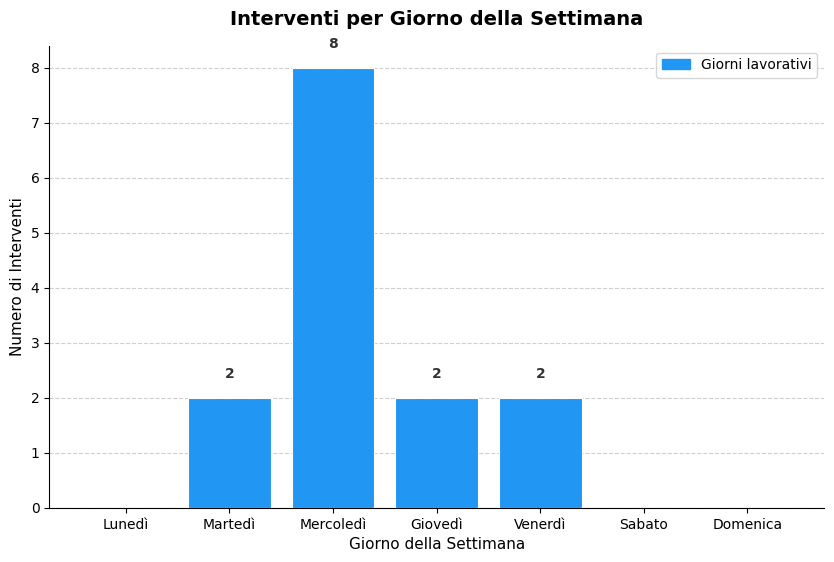

In [ ]:
giorni_map = {0: 'Lunedì', 1: 'Martedì', 2: 'Mercoledì', 
              3: 'Giovedì', 4: 'Venerdì', 5: 'Sabato', 6: 'Domenica'}

data['DATA_INTERVENTO'] = data['DATA_INTERVENTO'] + timedelta(days=1)
data['GIORNO_SETTIMANA'] = data['DATA_INTERVENTO'].dt.dayofweek
data['GIORNO_NOME'] = data['GIORNO_SETTIMANA'].map(giorni_map)

conteggio = data.groupby('GIORNO_SETTIMANA')['CODICE_INTERVENTO'].count().reindex(range(7), fill_value=0)
labels = [giorni_map[i] for i in range(7)]


# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2196F3' if i < 5 else '#FF7043' for i in range(7)]
bars = ax.bar(labels, conteggio.values, color=colors, edgecolor='white', linewidth=0.8, zorder=3)

# Griglia
ax.yaxis.grid(True, linestyle='--', alpha=0.6, zorder=0)
ax.set_axisbelow(True)

# Etichette sopra le barre
for bar in bars:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3, str(int(h)),
                ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333')

# Stile
ax.set_title('Arrib', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Giorno della Settimana', fontsize=11)
ax.set_ylabel('Numero di Interventi', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

# Legenda
patch_lav = mpatches.Patch(color='#2196F3', label='Giorni lavorativi')
ax.legend(handles=[patch_lav], loc='upper right')
plt.show()


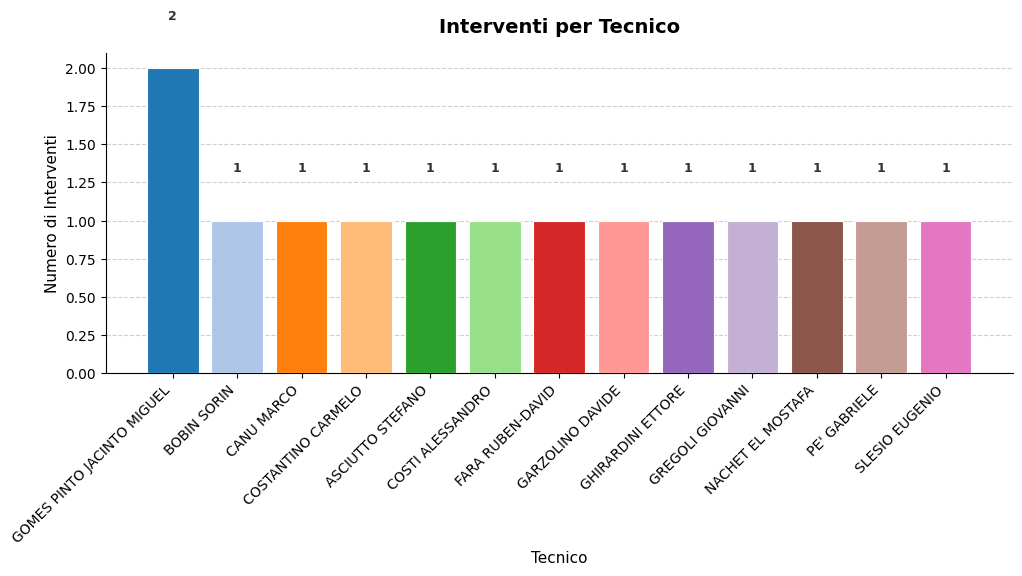

In [12]:
# Conta interventi per tecnico
conteggio_tecnico = (data.groupby('TECNICO')['CODICE_INTERVENTO']
                       .count()
                       .sort_values(ascending=False))

n_tecnici = len(conteggio_tecnico)

# Palette colori dinamica
colors = cm.tab20.colors[:n_tecnici] if n_tecnici <= 20 else cm.hsv(np.linspace(0, 0.9, n_tecnici))

# --- Plot ---
fig, ax = plt.subplots(figsize=(max(10, n_tecnici * 0.8), 6))

bars = ax.bar(conteggio_tecnico.index, conteggio_tecnico.values,
              color=colors, edgecolor='white', linewidth=0.8, zorder=3)

# Griglia
ax.yaxis.grid(True, linestyle='--', alpha=0.6, zorder=0)
ax.set_axisbelow(True)

# Etichette sopra le barre
for bar in bars:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3, str(int(h)),
                ha='center', va='bottom', fontsize=9, fontweight='bold', color='#333')

# Stile
ax.set_title('Interventi per Tecnico', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Tecnico', fontsize=11)
ax.set_ylabel('Numero di Interventi', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

# Ruota etichette asse X se ci sono molti tecnici
plt.xticks(rotation=45 if n_tecnici > 5 else 0, ha='right', fontsize=10)

plt.tight_layout()
plt.show()

0      0
1      0
2      0
3      0
4      0
5      0
6      0
7      0
9      1
10     1
17     2
18     2
169    6
170    6
Name: GIORNO_SETTIMANA, dtype: int32